# 10. 중립화는 그날 평균부터 지운다 — 이름이 연산의 절반만 말하고 있었다

> 2026-09-10 · 이동원 · 결론 문서: [전처리 v1.4](../../docs/전처리/version1.4/전처리-설계-명세서.md)

`preprocess_cross_section` 의 다섯 단계 중 ①②(winsorize · 횡단면 z)와 ⑤(시계열 z)는
[09-09 에 다 쟀고 전부 기각](../../docs/전처리/version1.3/전처리-설계-명세서.md)했습니다.
남은 것이 **③ 중립화**와 **④ 순위**입니다. 이 노트북이 그 둘을 같은 자리
(조합 K · LogisticRegression · 12폴드)에서 재고, **왜 그런지**까지 가릅니다.

이 판은 [노트북 05](05.횡단면-전처리는-날짜-안에서-끝난다.ipynb) 가 남긴 숙제이기도 합니다.
05 는 §6.1 에서 ICIR 이 0.1050 → **0.1144** 로 오르는 것을 보고 *"③ 중립화 = 업종 기본"*
이라고 §9 표에 적었고, 같은 노트북 §8.1 에서 *"그런데 3분류 정확도는 0.3938 → 0.3731 로
떨어졌다 · 이 노트북은 그 가설을 검증하지 않았다"* 라고 달아 두었습니다.

## 이 판에서 나온 것 셋

1. **③④ 둘 다 기각** — 원값을 넘은 것이 없습니다. 전처리 없음을 유지합니다.
2. 🔴 **음성 대조군으로 설계한 조건이 음성이 아니었습니다.** 시총은 라벨과 거의 무관한데
   (점이연 −0.0086) "시총 중립화" 가 원값 대비 −1.94%p 나빠졌습니다. 파 보니 **모든
   중립화가 설계행렬의 절편 때문에 그날 평균을 먼저 지웁니다.** 이름이 연산의 절반만
   말하고 있었습니다.
3. **05 의 §9 표를 뒤집습니다.** ICIR 로 고르면 "업종 중립화하라", 우리 판정 축
   (accuracy · [ADR 0007](../../docs/decisions/0007-최종-모델-선정과-홀드아웃.md))으로 고르면
   "하지 마라" 입니다. 05 는 그날의 기록이라 그대로 두고, 결론은 이 노트북과 전처리 v1.4 입니다.

## 순서

1. 무엇을 어떻게 쟀나 — 사전 등록
2. 돌리기 전에 잰 것 — 지우는 축이 라벨과 얼마나 이어져 있나
3. 판정 — 셋 다 기각
4. 🔴 예상이 F 에서 깨졌다
5. 왜 — 절편이 날짜 수준을 먼저 지운다
6. 몫을 가른다 — 날짜 · 자유도 · 업종 정보
7. 두 축이 다른 답을 낸다 — IC·ICIR vs accuracy
8. 정리

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from features.preprocessing import preprocess_cross_section  # noqa: E402
from features.stock_model_dataset import (  # noqa: E402
    STOCK_COMBINATION_FEATURES,
    align_stock_feature_datasets,
)
from scripts.run_stock_model_experiment import (  # noqa: E402
    load_stock_model_dataset,
)
from scripts.run_stock_preprocessing_axis import (  # noqa: E402
    with_shuffled_industry,
    with_size_control,
)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 깨짐을 막는다 — 맑은 고딕에는 U+2212(−)가 없어서
    fallback 체인과 `axes.unicode_minus=False` 를 함께 건다 (노트북 05 §0 과 같다)."""
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 네모로 나온다.\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv 뒤 런타임 재시작\n"
              "   Windows     : 맑은 고딕은 기본 설치다. matplotlib 캐시를 지우고 다시 실행한다")
        return "(없음)"
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return 찾음


폰트 = 한글폰트_설정()
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
     "violet": "#4a3aa7", "red": "#e34948", "gray": "#898781", "light": "#c3c2b7"}
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

보고 = json.loads((ROOT / "reports" / "stock_preprocessing_axis.json").read_text("utf-8"))
사전 = 보고["preregistration"]
print("python", sys.version.split()[0], "· pandas", pd.__version__, "· 한글 폰트", 폰트)
print("보고서", 보고["generated_at_utc"][:19], "· 벌", list(보고["sample_sets"]))

python 3.12.13 · pandas 3.0.3 · 한글 폰트 Malgun Gothic
보고서 2026-09-10T05:54:18 · 벌 ['full', 'mechanism', 'common']


## 1. 무엇을 어떻게 쟀나 — 사전 등록

09-09 와 **같은 자리**입니다. 조합 K · LogisticRegression · 12폴드 expanding · 홀드아웃
`20240901`. 바꾸는 것은 전처리 조건 하나뿐입니다.

바뀐 것 하나는 **조건이 두 갈래**라는 점입니다.

| | 무엇 | 다중검정 |
|---|---|---|
| **채택 후보** | E 업종 중립화 · F 시총 중립화 · H 순위(gaussian) | Bonferroni N 에 든다 |
| **탐색 조건** | D 그날 평균만 · R·R2 섞은 업종 | N 에 **안 든다** · 이것으로 채택하지 않는다 |

탐색 조건은 *"좋아지는가"* 를 묻는 것이 아니라 *"무엇 때문에 나빠지는가"* 를 가르려고
돌립니다. 임상시험 보고의 primary / exploratory 구분과 같습니다. 돌린 사실과 결과는
전부 싣되, 문턱이 보호하지 않으므로 채택 근거로 쓰지 않습니다.

**표본도 세 벌**입니다. `full` 로 판정하고(③④ 는 결측을 안 만들어 159,900행이 그대로
남습니다), `mechanism` 은 탐색 조건까지 넣은 벌, `common` 은 09-09(151,555행)와 이어붙이려고
B 를 끼운 벌입니다. **어느 벌로 판정하는지는 돌리기 전에 정했습니다** — 두 벌을 내고 나서
유리한 쪽을 고르면 그것이 곧 표본 선택입니다.

In [2]:
print("채택 후보:", 사전["candidates"])
print("탐색 조건:", 사전["exploratory"])
print(f"시행 N = {사전['trials_total']} (09-09 까지 {사전['trials_before']} + 이번 "
      f"{len(사전['candidates'])}) · Bonferroni α = {사전['bonferroni_alpha']:.5f}")
print("판정 벌:", 사전["verdict_sample_set"], "· 채택 기준:", 사전["acceptance"])
for 벌, 보 in 보고["sample_sets"].items():
    e, cs = 보["experiment"], 보["common_sample"]
    print(f"  {벌:10s} {e['rows']:,}행 · {e['codes']}종 · {e['dates']}일 "
          f"(뺀 행 {cs['rows_dropped']:,})")

채택 후보: ['E_neutralize_industry', 'F_neutralize_size', 'H_rank_gaussian']
탐색 조건: ['D_center_only', 'R_neutralize_shuffled_industry', 'R2_neutralize_shuffled_within_day']
시행 N = 10 (09-09 까지 7 + 이번 3) · Bonferroni α = 0.00500
판정 벌: full · 채택 기준: ADR 0007 — 기준선 대비 accuracy → macro F1 → 승리 폴드
  full       159,900행 · 157종 · 3343일 (뺀 행 0)
  mechanism  159,900행 · 157종 · 3343일 (뺀 행 0)
  common     151,555행 · 131종 · 3284일 (뺀 행 8,345)


## 2. 돌리기 전에 잰 것 — 지우는 축이 라벨과 얼마나 이어져 있나

09-09 에 B(종목별 시계열 z)를 **"라벨과 무관한 종목 고정효과를 지운다"** 고 설계했습니다.
기각된 뒤에야 종목 평균 `hv_20` 과 그 종목 비중립 비율의 Spearman ρ 가 **0.9413** 인 것을
쟀습니다. 통계 용어가 그럴듯해서 확인을 건너뛴 것입니다.

그래서 이번에는 **돌리기 전에** 쟀습니다. 라벨이 절대 ±2% 밴드라, *"그 축의 수준이 높으면
밴드를 더 자주 벗어나는가"* 가 곧 *"그 축이 라벨을 설명하는가"* 입니다.

이 증거는 **대상과 독립**입니다 — 중립화는 `hv_20` 을 업종 더미에 회귀할 뿐 라벨을 보지
않습니다. 라벨에서 파생한 값으로 라벨과의 상관을 쟀다면 그것은 대조가 아니라 항등식입니다.

**문턱을 고르지 않고 네 개로 재서 다 싣습니다.** 그룹을 몇 행 이상으로 자르느냐에 따라
값이 흔들리는데, 하나만 적으면 그것이 유리해서 고른 것인지 알 수 없기 때문입니다. 아래
표에서 업종 ρ 는 **0.79(전체 17업종) ~ 0.94(500행 이상 14업종)** 사이입니다. 어느 문턱에서도
"이어져 있다" 는 결론은 같고, **크기는 문턱에 따라 다릅니다.**

In [3]:
링크 = 보고["axis_label_link"]
행 = []
for 축, 표시 in [("stock_axis_erased_by_B", "종목 수준 (B 가 지운다)"),
               ("industry_axis_erased_by_E", "업종 수준 (E 가 지운다)"),
               ("date_axis_erased_by_cross_sectional_z", "날짜 수준 (모든 중립화·z·순위)")]:
    for 키, v in 링크[축].items():
        행.append({"축": 표시, "최소 행": int(키.split("_")[-1]), "그룹": v["groups"],
                   "Spearman rho": v.get("spearman_rho"),
                   "p": v.get("p_value"), "못 잰 이유": v.get("why_empty")})
display(pd.DataFrame(행).round(4))   # noqa: F821
시총 = 링크["size_axis_erased_by_F"]
print(f"\n시총 수준 (F 가 지운다) — 점이연 r = {시총['point_biserial_r']:+.4f} "
      f"(p = {시총['p_value']:.3g}) · 십분위 rho = {시총['decile_spearman_rho']:+.4f}")
print("  십분위 비중립: " + " ".join(f"{v:.4f}" for v in 시총["decile_nonneutral"]))

,축,최소 행,그룹,Spearman rho,p,못 잰 이유
0,종목 수준 (B 가 지운다),0,157,0.8733,0.0000,NaN
1,종목 수준 (B 가 지운다),100,119,0.9463,0.0000,NaN
2,종목 수준 (B 가 지운다),250,104,0.9413,0.0000,NaN
3,종목 수준 (B 가 지운다),500,83,0.9369,0.0000,NaN
4,업종 수준 (E 가 지운다),0,17,0.7868,0.0002,NaN
5,업종 수준 (E 가 지운다),100,15,0.8679,0.0000,NaN
6,업종 수준 (E 가 지운다),250,15,0.8679,0.0000,NaN
7,업종 수준 (E 가 지운다),500,14,0.9429,0.0000,NaN
8,날짜 수준 (모든 중립화·z·순위),0,3343,0.3242,0.0000,NaN
9,날짜 수준 (모든 중립화·z·순위),100,0,NaN,NaN,groups_below_3



시총 수준 (F 가 지운다) — 점이연 r = -0.0086 (p = 0.000554) · 십분위 rho = -0.4061
  십분위 비중립: 0.6187 0.6226 0.6339 0.6234 0.6283 0.6261 0.6306 0.5951 0.6037 0.6161


조합 K 159,900행 · 157종 · 3343일 · 피처 14칸 · 비중립 0.6198


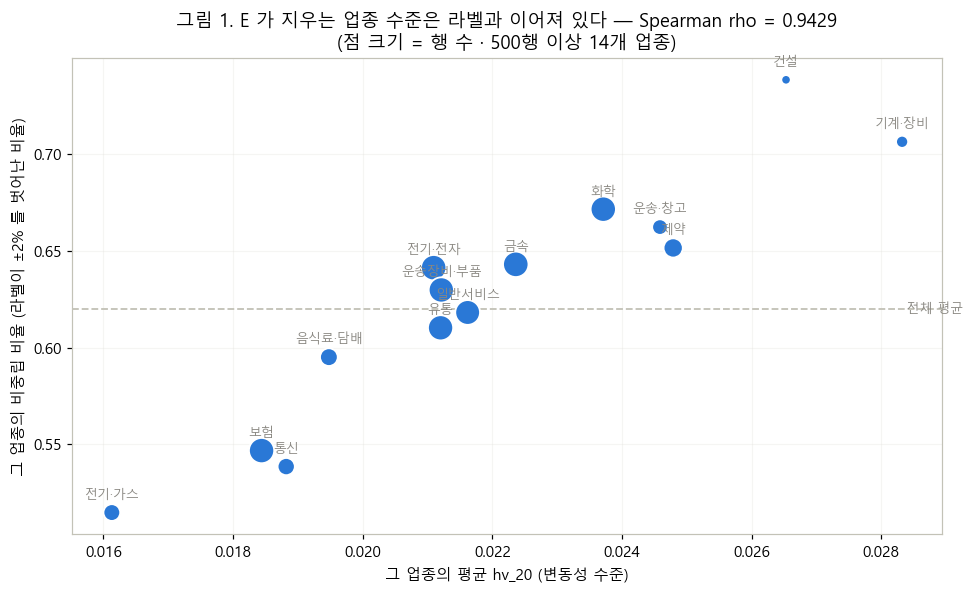

,행,비중립,hv
industry,,,
전기·가스,7229,0.5146,0.0161
보험,16405,0.5467,0.0184
통신,7632,0.5384,0.0188
음식료·담배,8092,0.5950,0.0195
전기·전자,16630,0.6413,0.0211
유통,16319,0.6102,0.0212
운송장비·부품,16375,0.6298,0.0212
일반서비스,15773,0.6181,0.0216
금속,16650,0.6431,0.0224


In [4]:
datasets = {name: load_stock_model_dataset(f)
            for name, f in STOCK_COMBINATION_FEATURES.items()}
base = with_shuffled_industry(with_size_control(align_stock_feature_datasets(datasets)["K"]))
panel = base.frame.copy()
FEATS = list(base.feature_columns)
panel["비중립"] = panel["label_numeric"].ne(0).astype(int)
print(f"조합 K {len(panel):,}행 · {panel['code'].nunique()}종 · "
      f"{panel['bas_dd'].nunique()}일 · 피처 {len(FEATS)}칸 · 비중립 {panel['비중립'].mean():.4f}")

업종표 = (panel.groupby("industry")
          .agg(행=("비중립", "size"), 비중립=("비중립", "mean"), hv=("hv_20", "mean"))
          .query("행 >= 500").sort_values("hv"))
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(업종표["hv"], 업종표["비중립"], s=업종표["행"] / 60, color=C["blue"],
           edgecolor="white", linewidth=1.2, zorder=3)
for 이름, r in 업종표.iterrows():
    ax.annotate(이름, (r["hv"], r["비중립"]), fontsize=8.5, color=C["gray"],
                xytext=(0, 9), textcoords="offset points", ha="center")
ax.axhline(panel["비중립"].mean(), color=C["light"], lw=1.2, ls="--")
ax.text(업종표["hv"].max(), panel["비중립"].mean(), " 전체 평균", va="center",
        fontsize=8.5, color=C["gray"])
rho = 링크["industry_axis_erased_by_E"]["min_rows_500"]["spearman_rho"]
ax.set_xlabel("그 업종의 평균 hv_20 (변동성 수준)")
ax.set_ylabel("그 업종의 비중립 비율 (라벨이 ±2% 를 벗어난 비율)")
ax.set_title(f"그림 1. E 가 지우는 업종 수준은 라벨과 이어져 있다 — Spearman rho = {rho:.4f}\n"
             f"(점 크기 = 행 수 · 500행 이상 {len(업종표)}개 업종)")
plt.tight_layout()
plt.show()
display(업종표.round(4))   # noqa: F821

## 3. 판정 — 셋 다 기각

채택 기준은 [ADR 0007](../../docs/decisions/0007-최종-모델-선정과-홀드아웃.md) 그대로
**기준선 대비 accuracy → Macro F1 → 승리 폴드**이고, **이번 실행의 원값을 넘어야** 채택입니다.

표에 승리 폴드가 **둘**인 것에 주의하십시오. `기준선이김` 은 다수 클래스 기준선을 이긴
폴드 수이고, `원값이김` 은 **원값을 이긴** 폴드 수입니다. 09-09 v1.3 §9 표의 *"이긴 폴드"* 는
뒤쪽입니다.

In [5]:
짧은이름 = {
    "raw": "원값", "E_neutralize_industry": "E 업종 중립화",
    "F_neutralize_size": "F 시총 중립화", "H_rank_gaussian": "H 순위",
    "D_center_only": "D 날짜평균만",
    "R_neutralize_shuffled_industry": "R 무작위·더미16",
    "R2_neutralize_shuffled_within_day": "R2 무작위·더미10",
}


def 조건표(벌: str) -> pd.DataFrame:
    보 = 보고["sample_sets"][벌]
    행 = []
    for 이름, rep in 보["conditions"].items():
        s, 비교 = rep["model_summary"], 보["paired_t_vs_raw"].get(이름)
        행.append({
            "조건": 이름,
            "종류": ("후보" if 이름 in 사전["candidates"]
                   else "탐색" if 이름 in 사전["exploratory"]
                   else "기준" if 비교 is None else "빌림"),
            "기준선대비": s["accuracy_minus_training_majority_baseline"],
            "원값대비": 비교["mean_difference"] if 비교 else np.nan,
            "원값이김": f"{비교['wins']}/{비교['folds']}" if 비교 else "—",
            "기준선이김": f"{int(s['baseline_win_folds'])}/{int(s['folds'])}",
            "p": 비교["p_value"] if 비교 else np.nan,
            "|IC|": rep["ic"]["abs_ic_mean"],
            "|ICIR|": rep["ic"]["abs_icir_mean"],
        })
    return pd.DataFrame(행).set_index("조건")


for 벌 in 보고["sample_sets"]:
    print(f"── 벌 {벌} · {보고['sample_sets'][벌]['experiment']['rows']:,}행 ──")
    display(조건표(벌).round(4))   # noqa: F821
판정 = 보고["verdict"]
print(f"\n판정({판정['sample_set']}): {판정['decision']}")
print(f"  명목 1위 {판정['nominal_best']} ({판정['nominal_best_difference']:+.4f}) · "
      f"Bonferroni α = {판정['bonferroni_alpha']:.5f}")

── 벌 full · 159,900행 ──


,종류,기준선대비,원값대비,원값이김,기준선이김,p,|IC|,|ICIR|
조건,,,,,,,,
raw,기준,0.0243,NaN,—,10/12,NaN,0.0206,0.0996
E_neutralize_industry,후보,-0.0104,-0.0347,2/12,5/12,0.0122,0.0183,0.1091
F_neutralize_size,후보,0.0049,-0.0194,3/12,8/12,0.0422,0.0206,0.1016
H_rank_gaussian,후보,0.0050,-0.0193,2/12,8/12,0.0089,0.0206,0.0996


── 벌 mechanism · 159,900행 ──


,종류,기준선대비,원값대비,원값이김,기준선이김,p,|IC|,|ICIR|
조건,,,,,,,,
raw,기준,0.0243,NaN,—,10/12,NaN,0.0206,0.0996
E_neutralize_industry,후보,-0.0104,-0.0347,2/12,5/12,0.0122,0.0183,0.1091
F_neutralize_size,후보,0.0049,-0.0194,3/12,8/12,0.0422,0.0206,0.1016
H_rank_gaussian,후보,0.0050,-0.0193,2/12,8/12,0.0089,0.0206,0.0996
D_center_only,탐색,0.0076,-0.0167,2/12,7/12,0.0738,0.0206,0.0996
R_neutralize_shuffled_industry,탐색,-0.0145,-0.0388,0/12,6/12,0.0040,0.0180,0.0944
R2_neutralize_shuffled_within_day,탐색,-0.0037,-0.0280,1/12,7/12,0.0139,0.0180,0.0922


── 벌 common · 151,555행 ──


,종류,기준선대비,원값대비,원값이김,기준선이김,p,|IC|,|ICIR|
조건,,,,,,,,
raw,기준,0.0132,NaN,—,7/12,NaN,0.0207,0.0998
B_ts_zscore_causal,빌림,-0.0149,-0.0281,1/12,3/12,0.0016,0.0188,0.0949
E_neutralize_industry,후보,-0.0097,-0.0228,3/12,6/12,0.0318,0.0177,0.1045
F_neutralize_size,후보,0.0021,-0.0111,4/12,8/12,0.2070,0.0211,0.1037
H_rank_gaussian,후보,0.0071,-0.0061,5/12,7/12,0.3860,0.0207,0.0998



판정(full): 채택 없음 — 전처리 없음(원값) 유지
  명목 1위 H_rank_gaussian (-0.0193) · Bonferroni α = 0.00500


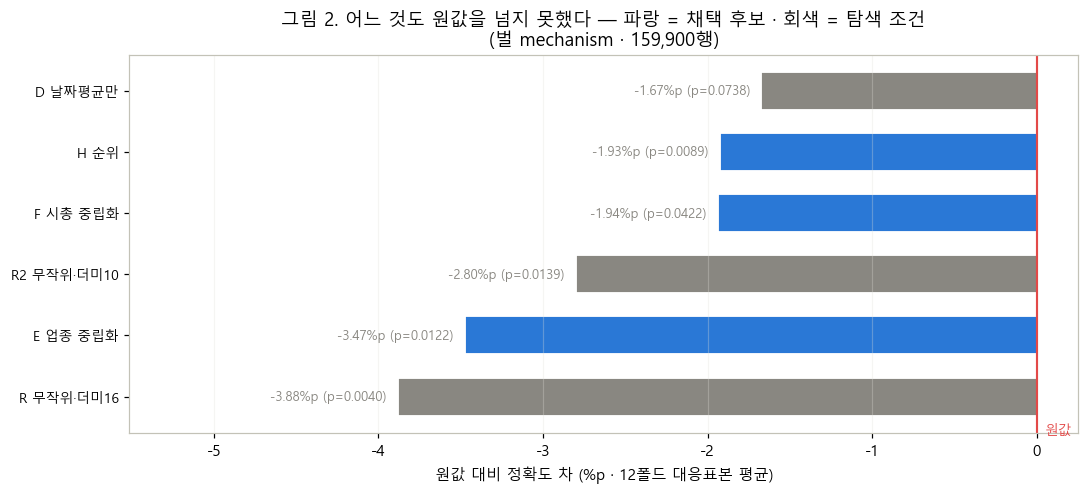

In [6]:
표 = 조건표("mechanism").drop(index="raw").sort_values("원값대비")
색 = [C["blue"] if v == "후보" else C["gray"] for v in 표["종류"]]
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh(range(len(표)), 표["원값대비"] * 100, color=색, height=0.62,
        edgecolor="white", linewidth=1.2)
# 값 라벨은 막대 **밖 왼쪽**에 회색으로 — 막대 안에 흰 글씨로 넣었더니 막대보다 왼쪽으로
# 밀려 흰 배경 위 흰 글씨가 되어 안 보였다.
ax.set_xlim(표["원값대비"].min() * 100 * 1.42, 0.25)
for i, (v, p) in enumerate(zip(표["원값대비"], 표["p"], strict=True)):
    ax.text(v * 100 - 0.07, i, f"{v * 100:+.2f}%p (p={p:.4f})", va="center", ha="right",
            fontsize=8.5, color=C["gray"])
ax.axvline(0, color=C["red"], lw=1.4)
ax.text(0.05, -0.55, "원값", color=C["red"], fontsize=9, va="center")
ax.set_yticks(range(len(표)))
ax.set_yticklabels([짧은이름[i] for i in 표.index], fontsize=9)
ax.set_xlabel("원값 대비 정확도 차 (%p · 12폴드 대응표본 평균)")
ax.set_title("그림 2. 어느 것도 원값을 넘지 못했다 — 파랑 = 채택 후보 · 회색 = 탐색 조건\n"
             f"(벌 mechanism · {보고['sample_sets']['mechanism']['experiment']['rows']:,}행)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. 🔴 예상이 F 에서 깨졌다

돌리기 전에 예상을 적어 두었습니다.

| 후보 | 지운다고 적은 것 | 라벨과의 상관 | 예상 |
|---|---|---:|---|
| E | 업종 수준 | ρ = 0.79 ~ 0.94 | 나빠진다 |
| **F** | **시총 수준** | **r = −0.0086** | **무해하다 — 음성 대조군** |
| H | 날짜·업종·종목 수준 전부 | — | 가장 나쁘다 |

E 는 맞았고 **F 와 H 가 틀렸습니다.** F 는 라벨과 거의 무관한 축을 지웠는데 −1.94%p
나빠졌고, H 는 가장 나쁘기는커녕 F 와 같은 자리(−1.93%p)에 섰습니다.

두 값이 **0.01%p 차이로 겹치는 것**이 실마리였습니다. 서로 다른 두 연산이 같은 크기로
나빠진다면, 둘이 공통으로 하는 일이 있다는 뜻입니다.

In [7]:
변환 = {
    "raw": panel[FEATS].astype(float),
    "D 날짜평균만": preprocess_cross_section(panel, FEATS, winsorize=None, zscore="center"),
    "E 업종중립화": preprocess_cross_section(
        panel, FEATS, winsorize=None, zscore=False,
        neutralize=dict(groups="industry", controls=())),
    "F 시총중립화": preprocess_cross_section(
        panel, FEATS, winsorize=None, zscore=False,
        neutralize=dict(groups=None, controls=("log_cap",))),
    "H 순위": preprocess_cross_section(
        panel, FEATS, winsorize=None, zscore=False, rank="gaussian"),
    "z 횡단면": preprocess_cross_section(panel, FEATS, winsorize=None, zscore=True),
}
날짜 = panel["bas_dd"]
행 = []
for 이름, X in 변환.items():
    평균 = X.groupby(날짜).mean().abs().to_numpy().max()
    산포 = X.groupby(날짜).std()
    비 = (산포.max() / 산포.min()).replace([np.inf, -np.inf], np.nan).median()
    행.append({"조건": 이름, "최대 |날짜별 평균|": 평균,
               "날짜별 표준편차 최대/최소 (중앙)": 비})
지움표 = pd.DataFrame(행).set_index("조건")
display(지움표)   # noqa: F821

,최대 |날짜별 평균|,날짜별 표준편차 최대/최소 (중앙)
조건,,
raw,6.766047e+01,7.550337
D 날짜평균만,9.422415e-15,7.550337
E 업종중립화,1.477929e-14,7.798772
F 시총중립화,1.811884e-13,7.732692
H 순위,6.961412e-03,1.000392
z 횡단면,1.126906e-15,1.000000


### 4.1 읽는 법 — 원값만 그날 평균을 갖고 있습니다

`raw` 의 최대 |날짜별 평균| 은 67 대인데 **나머지 다섯은 전부 1e-13 이하**입니다. 곧 0 입니다.

`neutralize_cross_section` 의 설계행렬에는 늘 절편이 들어갑니다 — `groups` 가 있으면 더미
전부가(그것이 절편 노릇을 합니다), 없으면 `1` 한 칸이. **절편이 있는 최소제곱의 잔차는
평균이 정확히 0** 입니다. 순위(④)도 그날 순위를 대칭 변환하므로 평균이 0 이고, 횡단면
z 는 정의상 0 입니다.

**그래서 F 와 H 가 겹쳤습니다.** 둘이 공통으로 하는 일은 "시총을 지운다"도 "순위로 바꾼다"도
아니라 **그날 평균을 지운다** 였습니다.

두 번째 칸이 갈리는 자리입니다. **중립화는 산포를 남깁니다**(raw 7.55 → F 7.73) — 평균만
빼고 나누지 않기 때문입니다. z 와 순위는 1.000 으로 산포까지 균일하게 만듭니다. 세 연산이
지우는 것이 서로 다릅니다.

## 5. 왜 — "시총 중립화" 의 대부분은 그냥 날짜 평균 빼기였습니다

말이 아니라 값으로 확인합니다. F 의 잔차와 **그날 평균만 뺀 값**을 피처마다 견줍니다.

`시총이 더 설명한 R²` 는 `1 − Σ(F 잔차)² / Σ(D 잔차)²` 입니다 — 그날 평균을 뺀 뒤에
시총 회귀가 **추가로** 없앤 분산의 비율입니다.

In [8]:
F, D = 변환["F 시총중립화"], 변환["D 날짜평균만"]
행 = []
for c in FEATS:
    a, b = F[c].to_numpy(dtype=float), D[c].to_numpy(dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    행.append({"피처": c, "상관(F, D)": np.corrcoef(a[ok], b[ok])[0, 1],
               "시총이 더 설명한 R²": 1 - np.sum(a[ok] ** 2) / np.sum(b[ok] ** 2)})
FD = pd.DataFrame(행).set_index("피처").sort_values("상관(F, D)")
display(FD.round(6))   # noqa: F821
print(f"상관 {FD['상관(F, D)'].min():.4f} ~ {FD['상관(F, D)'].max():.4f} · "
      f"시총 R² 평균 {FD['시총이 더 설명한 R²'].mean():.4f} "
      f"(최대 {FD['시총이 더 설명한 R²'].max():.4f})")

,"상관(F, D)",시총이 더 설명한 R²
피처,,
atr_ratio,0.956597,0.084923
rsi_14,0.974681,0.049998
sma_gap_20_60,0.975628,0.048150
bb_position,0.977069,0.045336
hv_20,0.977593,0.044312
bb_bandwidth,0.978506,0.042527
five_day_return,0.979283,0.041004
relative_ret_5_market,0.979283,0.041004
sma_gap_5_20,0.979358,0.040857


상관 0.9566 ~ 0.9831 · 시총 R² 평균 0.0446 (최대 0.0849)


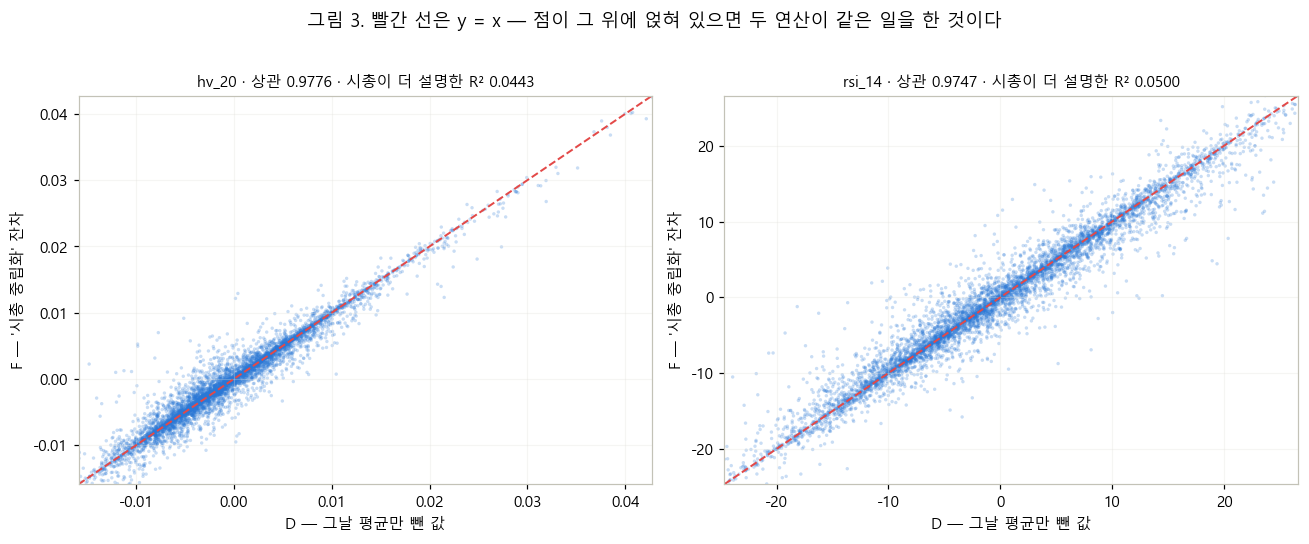

In [9]:
표본 = np.random.default_rng(0).choice(len(panel), size=6000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, c in zip(axes, ["hv_20", "rsi_14"], strict=True):
    a = F[c].to_numpy(dtype=float)[표본]
    b = D[c].to_numpy(dtype=float)[표본]
    ok = np.isfinite(a) & np.isfinite(b)
    ax.scatter(b[ok], a[ok], s=5, alpha=0.25, color=C["blue"], edgecolor="none")
    끝 = np.nanpercentile(np.concatenate([a[ok], b[ok]]), [0.5, 99.5])
    ax.plot(끝, 끝, color=C["red"], lw=1.3, ls="--")
    ax.set_xlim(*끝)
    ax.set_ylim(*끝)
    ax.set_xlabel("D — 그날 평균만 뺀 값")
    ax.set_ylabel("F — '시총 중립화' 잔차")
    ax.set_title(f"{c} · 상관 {FD.loc[c, '상관(F, D)']:.4f} · "
                 f"시총이 더 설명한 R² {FD.loc[c, '시총이 더 설명한 R²']:.4f}", fontsize=10)
fig.suptitle("그림 3. 빨간 선은 y = x — 점이 그 위에 얹혀 있으면 두 연산이 같은 일을 한 것이다",
             y=1.02)
plt.tight_layout()
plt.show()

### 5.1 그래서 이름이 틀렸습니다

상관 0.95~0.99, 시총이 **추가로** 설명한 몫은 평균 4~5%. `groups=None, controls=("log_cap",)`
를 *"시총만 중립화"* 라고 부르고 음성 대조군으로 삼았는데, 그 연산이 실제로 한 일의
95% 는 **그날 평균 빼기**였습니다. 그리고 날짜 수준은 라벨과 무관하지 않습니다 — 날짜별
평균 `hv_20` 과 그날 비중립 비율의 Spearman ρ 가 0.32 대입니다(§2 표).

`features/preprocessing.py` 의 docstring 이 이 갈래를 *"시총만"* 이라고 적어 두고 있었습니다.
고쳤고, **어느 축을 지우든 그날 평균이 함께 0 이 된다**를 시험 넷으로 못박았습니다
(`test_어느_축을_지우든_그날_평균이_함께_0_이_된다`).

## 6. 몫을 가른다 — 날짜 · 자유도 · 업종 정보

D 를 기준선으로 두면 각 조건이 **D 위에 무엇을 더 얹었는지**로 손실이 갈립니다.

R 과 R2 는 둘 다 업종 라벨을 섞어 중립화하지만 섞는 단위가 다릅니다.

| | 섞는 단위 | 하루 업종 수 | 무엇을 재나 |
|---|---|---|---|
| R | 종목 | 10 → **16** | 자유도를 **더** 썼을 때 |
| **R2** | **그날 안** | **10 그대로** | 자유도를 **맞췄을 때** |

🔴 처음에는 R 하나만 두었는데 **자유도가 안 맞았습니다.** 우리 후보군은 *"업종 시총 상위
10 × 업종별 상위 5"* 규칙으로 뽑혀 하루 업종이 정확히 10개인데, 종목 단위로 섞으니 그 짝이
흩어져 16개가 되었습니다. 그래서 **E 와 견줄 수 있는 것은 R2 입니다.**

,무엇,%p
단계,,
raw → D,그날 평균 (모든 중립화·z·순위가 공통으로 한다),-1.673
D → F,시총 축을 더 지운 몫,-0.266
D → R2,더미 10개를 세우느라 잃은 몫 (정보는 안 지움),-1.126
D → E,더미 10개 + 진짜 업종 정보,-1.798
R2 → E,업종 정보만의 몫 (자유도가 같다),-0.673
R2 → R,더미를 10 → 16 으로 늘린 몫,-1.083


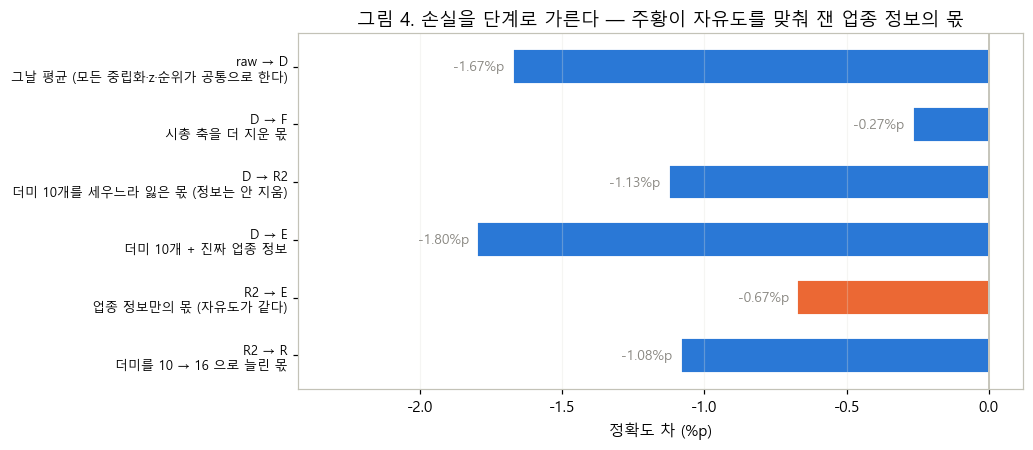

In [10]:
기 = 조건표("mechanism")["원값대비"]
단계 = [
    ("raw → D", "그날 평균 (모든 중립화·z·순위가 공통으로 한다)",
     기.get("D_center_only", np.nan)),
    ("D → F", "시총 축을 더 지운 몫", 기["F_neutralize_size"] - 기["D_center_only"]),
    ("D → R2", "더미 10개를 세우느라 잃은 몫 (정보는 안 지움)",
     기["R2_neutralize_shuffled_within_day"] - 기["D_center_only"]),
    ("D → E", "더미 10개 + 진짜 업종 정보", 기["E_neutralize_industry"] - 기["D_center_only"]),
    ("R2 → E", "업종 정보만의 몫 (자유도가 같다)",
     기["E_neutralize_industry"] - 기["R2_neutralize_shuffled_within_day"]),
    ("R2 → R", "더미를 10 → 16 으로 늘린 몫",
     기["R_neutralize_shuffled_industry"] - 기["R2_neutralize_shuffled_within_day"]),
]
몫 = pd.DataFrame(단계, columns=["단계", "무엇", "%p"]).set_index("단계")
몫["%p"] = (몫["%p"] * 100).round(3)
display(몫)   # noqa: F821

fig, ax = plt.subplots(figsize=(9.5, 4.2))
y = np.arange(len(몫))
# 이모지는 matplotlib 폰트에 없어 두부로 나온다 — 강조는 색으로만 한다.
색 = [C["orange"] if i == "R2 → E" else C["blue"] for i in 몫.index]
ax.barh(y, 몫["%p"], color=색, height=0.6, edgecolor="white", linewidth=1.2)
for i, v in enumerate(몫["%p"]):
    ax.text(v - 0.03 if v < 0 else v + 0.03, i, f"{v:+.2f}%p", va="center",
            ha="right" if v < 0 else "left", fontsize=9, color=C["gray"])
ax.axvline(0, color=C["light"], lw=1.2)
# 가장 긴 막대의 값 라벨이 축 밖으로 나가 y축 글씨와 겹치지 않게 왼쪽에 여백을 준다.
ax.set_xlim(몫["%p"].min() * 1.35, 0.12)
ax.set_yticks(y)
ax.set_yticklabels([f"{i}\n{w}" for i, w in zip(몫.index, 몫["무엇"], strict=True)],
                   fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("정확도 차 (%p)")
ax.set_title("그림 4. 손실을 단계로 가른다 — 주황이 자유도를 맞춰 잰 업종 정보의 몫")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 7. 두 축이 다른 답을 낸다 — 05 노트북 §9 표를 뒤집습니다

[노트북 05](05.횡단면-전처리는-날짜-안에서-끝난다.ipynb) §6.1 은 같은 자료에서 이렇게
쟀습니다.

```
          |IC| 평균   |ICIR| 평균
원값        0.0211     0.1050
+업종       0.0191     0.1144      ← ICIR 이 8.9% 오른다
+시총       0.0211     0.1063
+업종+시총   0.0180     0.1085
```

그리고 §9 표에 *"③ 중립화 — **업종 기본** · 시총은 필요할 때만"* 이라고 적었습니다.
근거는 *"랭킹에서는 한 번 크게 맞히는 것보다 매일 조금씩 맞히는 것이 낫고, 그 기준이
ICIR"* 이었습니다.

**이번 판에서 그 ICIR 상승이 그대로 재현됩니다.** 그런데 우리 판정 축인 accuracy 는 반대로
움직입니다. 그리고 **무작위 업종(R·R2)에서는 ICIR 이 오르지 않습니다** — 곧 ICIR 상승은
진짜 업종 정보를 지운 덕입니다. 같은 연산이 한 축에서는 이득, 다른 축에서는 손해입니다.

한 자리 더 짚어 둡니다 — **H(순위)의 IC·ICIR 은 원값과 소수 넷째 자리까지 같습니다**
(0.0206 · 0.0996). 우연이 아니라 정의입니다. IC 는 **순위상관**이고 순위 변환은 그날 안
순서를 그대로 두므로 값이 바뀔 수 없습니다(05 §6.2 ①이 `winsor+z` 에서 같은 것을
지적했습니다). **IC 로는 ④ 를 아예 잴 수 없고**, 그런데도 accuracy 는 −1.93%p 움직입니다 —
로지스틱이 순위가 아니라 **값의 크기**를 쓰기 때문입니다. 축을 잘못 고르면 *"아무 일도
일어나지 않았다"* 는 결론이 나옵니다.

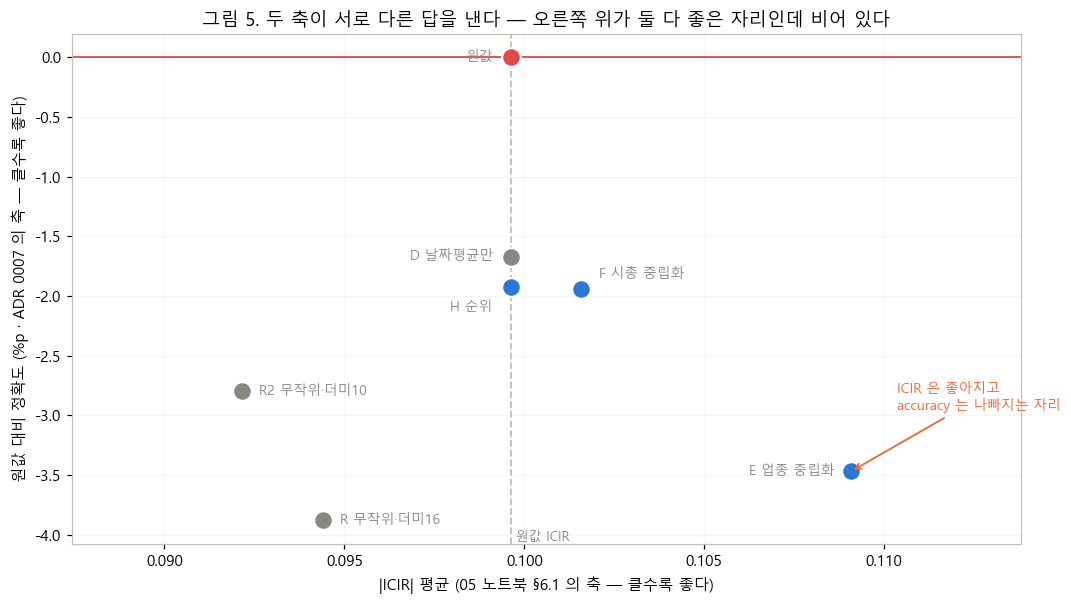

In [11]:
표 = 조건표("mechanism")
기준ICIR = 표.loc["raw", "|ICIR|"]
fig, ax = plt.subplots(figsize=(10, 5.6))
# x 여백을 먼저 잡는다 — 안 그러면 왼쪽 끝 점의 라벨이 축 밖으로 나가 y축 글씨를 덮는다.
폭 = 표["|ICIR|"].max() - 표["|ICIR|"].min()
ax.set_xlim(표["|ICIR|"].min() - 폭 * 0.28, 표["|ICIR|"].max() + 폭 * 0.28)
# H 와 F 는 정확도가 0.01%p 차이라 점이 거의 포개진다 — 그 둘만 위아래로 벌린다.
겹침 = {"H_rank_gaussian": (-12, -13), "F_neutralize_size": (12, 9)}
for 이름, r in 표.iterrows():
    색 = (C["red"] if 이름 == "raw" else C["blue"] if r["종류"] == "후보" else C["gray"])
    x = r["|ICIR|"]
    y = (0.0 if 이름 == "raw" else r["원값대비"]) * 100
    ax.scatter(x, y, s=150, color=색, edgecolor="white", linewidth=1.4, zorder=3)
    # 기준선 왼쪽 점은 라벨을 오른쪽에, 오른쪽 점은 왼쪽에 — 서로 겹치지 않게.
    dx, dy = 겹침.get(이름, (11 if x < 기준ICIR else -11, 0))
    ax.annotate(짧은이름[이름], (x, y), fontsize=9, color=C["gray"], zorder=4,
                xytext=(dx, dy), textcoords="offset points",
                va="center", ha="left" if dx > 0 else "right")
ax.axvline(기준ICIR, color=C["light"], lw=1.2, ls="--")
ax.axhline(0, color=C["red"], lw=1.2)
ax.text(기준ICIR, ax.get_ylim()[0], " 원값 ICIR", va="bottom", fontsize=8.5, color=C["gray"])
ax.annotate("ICIR 은 좋아지고\naccuracy 는 나빠지는 자리",
            xy=(표.loc["E_neutralize_industry", "|ICIR|"],
                표.loc["E_neutralize_industry", "원값대비"] * 100),
            xytext=(30, 40), textcoords="offset points", fontsize=9, color=C["orange"],
            arrowprops=dict(arrowstyle="->", color=C["orange"], lw=1.2))
ax.set_xlabel("|ICIR| 평균 (05 노트북 §6.1 의 축 — 클수록 좋다)")
ax.set_ylabel("원값 대비 정확도 (%p · ADR 0007 의 축 — 클수록 좋다)")
ax.set_title("그림 5. 두 축이 서로 다른 답을 낸다 — 오른쪽 위가 둘 다 좋은 자리인데 비어 있다")
plt.tight_layout()
plt.show()

## 8. 정리

| | 결론 | 근거 |
|---|---|---|
| **③ 중립화** | ❌ 안 한다 | 업종 −3.47%p · 시총 −1.94%p (원값 대비 · 12폴드) |
| **④ 순위** | ❌ 안 한다 | gaussian −1.93%p |
| 전처리 전체 | ✅ **원값 유지** | 후보 여덟(A·A′·B·C·D·E·F·H) 중 원값을 넘은 것 0 |
| 손실의 절반 | **그날 평균 빼기** 하나 | D 단독으로 −1.67%p — 중립화·z·순위가 공통으로 한다 |
| 업종 정보의 몫 | 자유도를 맞춘 R2 와 견줘야 읽힌다 | §6 표 |
| ICIR vs accuracy | **두 축이 반대** | §7 — 05 §9 표의 "업종 기본" 은 ICIR 축의 답이다 |

### 남는 것

- **05 노트북은 고치지 않습니다.** 그날의 실행 기록이고, §8.1 에 *"이 노트북은 그 가설을
  검증하지 않았다"* 가 이미 달려 있습니다. 결론은 이 노트북과
  [전처리 v1.4](../../docs/전처리/version1.4/전처리-설계-명세서.md) 입니다.
- **라벨이 상대 목표로 바뀌면 ③④ 는 그대로 쓸 수 있습니다.** 함수·시험이 남아 있고,
  ICIR 축에서는 실제로 이득입니다. 우리 라벨이 절대 ±2% 밴드일 뿐입니다.
- **이름이 연산의 절반만 말할 수 있습니다.** "시총 중립화" 도 "종목 고정효과"(09-09)도
  그랬습니다. 다음부터는 **무엇을 지우는지 값으로 먼저 확인**하고 이름을 믿지 않습니다.